In [ ]:
# !pip uninstall numpy -y
# !pip install numpy==1.26.4

In [ ]:
# installing necessary libraries
!pip install contractions
!pip install fasttext
!wget https://dl.fbaipublicfiles.com/fasttext/supervised-models/lid.176.bin

  Using cached fasttext-0.9.3.tar.gz (73 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached pybind11-3.0.1-py3-none-any.whl.metadata (10.0 kB)
Using cached pybind11-3.0.1-py3-none-any.whl (293 kB)
  Created wheel for fasttext: filename=fasttext-0.9.3-cp312-cp312-linux_x86_64.whl size=4498210 sha256=26029d8ad3e71cedcac423cc5a7c5c0cfa267bccfe6aa64113b53e4aac8ec7e9
  Stored in directory: /root/.cache/pip/wheels/20/27/95/a7baf1b435f1cbde017cabdf1e9688526d2b0e929255a359c6
Successfully built fasttext
--2026-01-17 14:47:30--  https://dl.fbaipublicfiles.com/fasttext/supervised-models/lid.176.bin
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 18.155.173.40, 18.155.173.116, 18.155.173.79, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|18.155.173.40|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 131266198 (125M) [application/octet-strea

In [ ]:
# importing the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import re
import math
import contractions
import nltk
from nltk.corpus import reuters
from nltk.corpus import stopwords
import fasttext

In [ ]:
pd.set_option('display.max_colwidth', None)

In [ ]:
df = pd.read_csv('bitcoin_sentiment_dataset.csv')
df.shape

(1000, 5)

In [ ]:
df.head(10)

,id,timestamp,tweet,sentiment,followers
0,1,2024-01-07 02:00:00,Sold all my BTC. Too risky and unpredictable for me. #Bitcoin,negative,47
1,2,2024-01-30 04:00:00,Follow me for daily Bitcoin giveaways! Next one in 1 hour! 🎁 #BTC #Giveaway,negative,7
2,3,2024-01-30 11:00:00,比特币是庞氏骗局 #比特币 #骗局,negative,135
3,4,2024-01-02 12:00:00,Sovereign individual through Bitcoin! #BTC #Freedom,positive,189
4,5,2024-01-22 10:00:00,🇧🇷 Bitcoin no Brasil está crescendo muito! #Bitcoin #Cripto,positive,4
5,6,2024-01-13 22:00:00,Institutional adoption of BTC continues to grow. This is just the beginning. #Bitcoin,positive,19
6,7,2024-01-12 02:00:00,Elon Musk LIVE GIVEAWAY happening NOW! Send 0.1 BTC get 1 BTC back! ⚡ #Bitcoin #ElonMusk,negative,4
7,8,2024-01-03 10:00:00,Bitcoin reaching new highs in my country! 🇮🇳 #Bitcoin,positive,482
8,9,2024-01-11 13:00:00,Historical Bitcoin drawdowns compared to current levels. 📊,neutral,117
9,10,2024-01-17 00:00:00,💰 VIP SIGNALS GROUP 💰 99.7% win rate! Join now $99/month! DM me! #Trading #Signals,negative,47


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         1000 non-null   int64 
 1   timestamp  1000 non-null   object
 2   tweet      1000 non-null   object
 3   sentiment  1000 non-null   object
 4   followers  1000 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 39.2+ KB


In [ ]:
df.isna().sum()

,0
id,0
timestamp,0
tweet,0
sentiment,0
followers,0


In [ ]:
def date_preprocess(data):
  # Convert to datetime type, invalid ones → NaT (Not a Time)
  data['timestamp'] = pd.to_datetime(data['timestamp'], errors='coerce')
  # Remove rows with invalid date, ie, removing NaT values
  date = data.dropna(subset=['timestamp'])
  return date

In [ ]:
df = date_preprocess(df)
df.head(10)

,id,timestamp,tweet,sentiment,followers
0,1,2024-01-07 02:00:00,Sold all my BTC. Too risky and unpredictable for me. #Bitcoin,negative,47
1,2,2024-01-30 04:00:00,Follow me for daily Bitcoin giveaways! Next one in 1 hour! 🎁 #BTC #Giveaway,negative,7
2,3,2024-01-30 11:00:00,比特币是庞氏骗局 #比特币 #骗局,negative,135
3,4,2024-01-02 12:00:00,Sovereign individual through Bitcoin! #BTC #Freedom,positive,189
4,5,2024-01-22 10:00:00,🇧🇷 Bitcoin no Brasil está crescendo muito! #Bitcoin #Cripto,positive,4
5,6,2024-01-13 22:00:00,Institutional adoption of BTC continues to grow. This is just the beginning. #Bitcoin,positive,19
6,7,2024-01-12 02:00:00,Elon Musk LIVE GIVEAWAY happening NOW! Send 0.1 BTC get 1 BTC back! ⚡ #Bitcoin #ElonMusk,negative,4
7,8,2024-01-03 10:00:00,Bitcoin reaching new highs in my country! 🇮🇳 #Bitcoin,positive,482
8,9,2024-01-11 13:00:00,Historical Bitcoin drawdowns compared to current levels. 📊,neutral,117
9,10,2024-01-17 00:00:00,💰 VIP SIGNALS GROUP 💰 99.7% win rate! Join now $99/month! DM me! #Trading #Signals,negative,47


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   id         1000 non-null   int64         
 1   timestamp  1000 non-null   datetime64[ns]
 2   tweet      1000 non-null   object        
 3   sentiment  1000 non-null   object        
 4   followers  1000 non-null   int64         
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 39.2+ KB


In [ ]:
# all tweets are from the same day at different time zones
df.timestamp.min(), df.timestamp.max()

(Timestamp('2024-01-01 00:00:00'), Timestamp('2024-01-31 00:00:00'))

In [ ]:
df.shape

(1000, 5)

In [ ]:
SPAM_KEYWORDS = {
    "GIVEAWAY": [
        "giveaway", "airdrop", "free crypto", "free bitcoin", "free btc",
        "free eth", "free tokens", "free coins", "claim now", "free money",
        "win crypto", "prize", "contest", "drop your wallet", "enter to win",
        "winner announced", "winner in", "tag 3 friends", "tag friends",
        "must follow", "drop your btc", "drop your eth"
    ],
    "PROMOTIONAL": [
        "click here", "link in bio", "check out", "visit our",
        "sign up now", "register now", "download now", "promo code",
        "discount code", "referral code", "affiliate", "sponsored",
        "dm for access", "dm to join", "dm me", "check pinned"
    ],
    "ENGAGEMENT": [
        "retweet and follow", "rt and follow", "like and rt",
        "follow and rt", "tag friends", "follow me", "follow back", "f4f",
        "rt to enter", "follow + rt", "must follow"
    ],
    "PUMP_DUMP": [
        "100x", "1000x", "moon", "to the moon", "buy now",
        "pump incoming", "whale alert", "hidden gem", "moonshot",
        "next bitcoin", "ground floor"
    ],
    "GUARANTEED_RETURNS": [
        "guaranteed profit", "guaranteed returns", "100% profit",
        "no risk", "risk free", "double your", "passive income", "easy money",
        "guaranteed"
    ],
    "URGENCY": [
        "urgent buy", "hurry up", "act now", "don't miss",
        "ending soon", "expires soon", "limited time", "today only",
        "in next 48 hours", "within 1 hour", "closes tonight",
        "last 2 hours", "final warning", "last chance", "ends tonight",
        "limited spots"
    ],
    "MLM_SCHEME": [
        "investment opportunity", "business opportunity",
        "financial independence", "mlm", "pyramid", "ponzi", "refer and earn"
    ],
    "PHISHING": [
        "verify your wallet", "confirm your wallet",
        "account suspended", "seed phrase", "private key",
        "wallet flagged", "security alert", "unauthorized access"
    ],
    "TRADING_SIGNAL": [
        "trading signal", "buy signal", "vip signal",
        "premium signal", "free signal", "never lose",
        "win rate", "vip group"
    ],
    "ICO_PRESALE": [
        "presale live", "presale now", "ico live",
        "token launch", "launching soon", "token sale",
        "presale ending", "token sale closes"
    ],
    "BOT": [
        "trading bot", "auto trade", "automated trading",
        "profit bot", "increase balance", "autopilot"
    ],
    "RECOVERY_SCAM": [
        "recovery service", "recover funds",
        "hacked wallet", "fund recovery"
    ],
    "CELEBRITY": [
        "elon musk", "elon said", "musk announced",
        "as seen on cnn", "as seen on bbc", "vitalik buterin",
        "vitalik", "buterin", "cz binance", "michael saylor"
    ],
    "LOW_QUALITY": [
        "gm crypto", "gn crypto", "wagmi", "ngmi",
        "wen moon", "wen lambo"
    ],
    "EMOJI_SPAM": [],  # Handled separately
    "NFT_SPAM": [
        "nft giveaway", "nft airdrop",
        "free nft", "mint now", "nft drop", "free mint"
    ]
}

In [ ]:
SPAM_WEIGHTS_NEW = {
    "GIVEAWAY": 2.8,           # Increased from 2.5
    "PROMOTIONAL": 2.0,
    "ENGAGEMENT": 1.8,         # Increased from 1.5
    "PUMP_DUMP": 3.5,
    "GUARANTEED_RETURNS": 5.0,
    "URGENCY": 2.8,            # Increased from 2.5
    "MLM_SCHEME": 4.5,
    "PHISHING": 5.0,
    "TRADING_SIGNAL": 4.0,
    "ICO_PRESALE": 3.0,
    "BOT": 4.0,
    "RECOVERY_SCAM": 5.0,
    "CELEBRITY": 1.5,          # Increased from 1.0
    "LOW_QUALITY": 0.5,
    "EMOJI_SPAM": 1.8,         # Increased from 1.5
    "NFT_SPAM": 3.0
}

EMOJIS = ["🚀", "🔥", "💎", "🌙", "🛑", "💰", "⭐", "📢", "⚡", "🎁", "⚠️", "🔴", "🐋", "🖼️", "🎨", "🎯", "🔮"]

ENGAGEMENT_PAIRS = [
    ("follow", "rt"),
    ("rt", "follow"),
    ("like", "rt"),
    ("retweet", "follow"),
]

In [ ]:
def count_emojis(text):
    # Count emojis with bonus for repeated patterns
    emoji_pattern = r'([🚀🔥💎🌙🛑💰⭐📢⚡🎁⚠️🔴🐋🖼️🎨🎯🔮])\1{2,}'
    repeated = len(re.findall(emoji_pattern, text))
    total = sum(text.count(e) for e in EMOJIS)
    return total + (repeated * 2)

def engagement_hit(text):
    # Check for engagement bait patterns
    return any(all(w in text for w in pair) for pair in ENGAGEMENT_PAIRS)

def numeric_giveaway(text):
    # Detect giveaways with specific amounts
    return bool(re.search(r'(win|giveaway|giving away)\s+\d+\s*(btc|eth|usdt)', text, re.IGNORECASE))

def doubling_scam(text):
    # Detect 'send X get 2X back' scams
    return bool(re.search(r'send\s+[\d.]+.*get\s+[\d.]+.*back', text, re.IGNORECASE))

def has_suspicious_url(text):
    # Check for suspicious URLs
    suspicious = [
        'bit.ly', 'tinyurl', 'goo.gl',
        '.scam', '-fake', 'fake.com',
        'opensea-', 'metamask-', 'binance-', 'coinbase-',
        'claim-', 'verify-', 'secure-'
    ]
    return any(pattern in text for pattern in suspicious)

def is_spam(text, threshold=3.5):  # Lowered from 4.0
    """
    Detect spam content with multi-signal scoring

    Args:
        text: Input text to analyze
        threshold: Score threshold for spam classification (default: 3.5)

    Returns:
        tuple: (is_spam: bool, score: float)
    """
    text_lower = text.lower()
    score = 0.0
    matched_categories = 0

    # URL check - counts as independent signal
    if has_suspicious_url(text_lower):
        score += 3.0
        matched_categories += 1

    # Doubling scam check - very suspicious
    if doubling_scam(text_lower):
        score += 4.0
        matched_categories += 1

    # Process each category
    for category, keywords in SPAM_KEYWORDS.items():
        hits = 0

        if category == "EMOJI_SPAM":
            # Special handling for emojis
            emoji_count = count_emojis(text)
            if emoji_count >= 3:
                hits = emoji_count
        else:
            # Normal keyword matching
            for kw in keywords:
                hits += text_lower.count(kw)

        # Category-specific semantic boosts
        if category == "GIVEAWAY":
            if numeric_giveaway(text_lower):
                hits += 2  # Increased from 1

        if category == "ENGAGEMENT":
            if engagement_hit(text_lower):
                hits += 2  # Increased from 1

        # Add to score if category matched
        if hits > 0:
            matched_categories += 1
            score += SPAM_WEIGHTS_NEW[category] * math.log1p(hits)

    # Multi-signal requirement with severity exceptions
    if matched_categories == 1 and score < 4.5:
        return False, score
    elif matched_categories < 2 and score < 3.5:
        return False, score

    return score >= threshold, score

In [ ]:
# finding the no. of hashtags in the tweets
def count_hashtags(text):
    return len(re.findall(r"#\w+", text))

In [ ]:
def filtering_pipeline(text, followers, threshold=3.5):
  # tweets from account with fewer than 10 followers were removed
  if followers < 10:
      return True

  # filtering tweets with excessive hashtags (>5)
  if count_hashtags(text) > 5:
    return True

  # calling the is_spam() function to check whether a tweet is spam or not
  is_spam_content, score = is_spam(text, threshold)
  if is_spam_content:
      return True

  return False


In [ ]:
# applying the above spam filtering function and filter the tweets
df['is_spam'] = df.apply(lambda x: filtering_pipeline(x['tweet'], x['followers']), axis=1)
df = df[df['is_spam'] == False]
df.shape

(756, 6)

In [ ]:
CRYPTO_HASHTAG_VOCAB = {
    # Coins / assets
    "bitcoin", "btc", "ethereum", "eth", "bnb", "solana", "sol",
    "xrp", "dogecoin", "doge", "cardano", "ada",

    # Market sentiment
    "bullish", "bearish", "bullrun", "bearmarket",
    "moon", "to_the_moon", "pump", "dump",
    "breakout", "breakdown", "rally", "crash",

    # Price & metrics
    "ath", "atl", "high", "low",
    "resistance", "support",
    "volume", "volatility", "dominance",

    # Trading actions
    "buy", "sell", "hold", "hodl",
    "long", "short", "leverage",
    "entry", "exit", "takeprofit", "stoploss",

    # News & events
    "etf", "halving", "airdrop",
    "listing", "delisting",
    "regulation", "sec", "fed",

    # Slang / emotions
    "fomo", "fud", "rekt", "ngmi", "wagmi",
    "lfg", "gm", "gn"
}

In [ ]:
# download necessary hastag words (reuters) from nltk
nltk.download('reuters')

# Build Reuters English vocabulary which will use to expand words
REUTERS_VOCAB = set(word.lower() for word in reuters.words())
# Addin some crypto related hashtag wors to the REUTERS_VOCAB
REUTERS_VOCAB.update(CRYPTO_HASHTAG_VOCAB)

[nltk_data] Downloading package reuters to /root/nltk_data...


In [ ]:
CRYPTO_SLANG_ACRONYM_MAP = {
    # Slang terms
    "hodl": "hold",
    "fomo": "fear of missing out",
    "fud": "fear uncertainty doubt",
    "rekt": "financially ruined",
    "moon": "price increase rapidly",
    "dump": "sharp price fall",
    "pump": "artificial price increase",
    "bagholder": "investor holding losses",
    "whale": "large investor",
    "bearish": "expecting price fall",
    "bullish": "expecting price rise",
    "ath": "all time high",
    "atl": "all time low",

    # Acronyms
    "btd": "buy the dip",
    "dyor": "do your own research",
    "ngmi": "not going to make it",
    "wagmi": "we are going to make it",
    "lmao": "laughing my ass off",
    "imo": "in my opinion",
    "idk": "i do not know"
}


In [ ]:
# download stopword sets from nltk
nltk.download('stopwords')

# stop words are words that less or no contribute to the sentiments such as the, to, an, and, etc
STOP_WORDS = set(stopwords.words('english'))
# Preserve negations which has a large contributions to sentiments
NEGATIONS = {"not", "no", "nor", "never", "don't", "dont", "can't",
             "won't", "n't", "cant", "cannot", "wont", "doesnot",
             "didnot", "didn't", "doesn't"}
STOP_WORDS = STOP_WORDS - NEGATIONS

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
# text or tweets are preprocessing using regular expressiond (re -> python library)
def text_preprocessing(text):
  # removing retweets like: "RT @user: text"
  text = re.sub(r'(?i)^\s*rt\s+@?\w+:?', '', text)

  # first removing the urls from the tweets
  text = re.sub(r'https?://\S+|www\.\S+', '', text) # \S -> all characters including nums and special symbls until a space or newline chars

  # removing the mentions, (?<!\w)@ -> checking the char immediately before @ is a space not a letter, num or any other char
  text = re.sub(r'(?<!\w)@[a-zA-Z0-9_]+', '', text)

  # removing extra spaces and newline characters into a single space
  text = re.sub(r'\s+', ' ', text)
  text = text.strip() # removing leading and trailing spaces

  # shorten repeated characters, nooooo -> noo
  text = re.sub(r'(.)\1{3,}', r'\1\1\1', text)

  # lowercasing all the characters in the text excluding hashtags
  text = text.lower()

  # removing short tweets, length of words < 4
  if len(text.split()) < 4:
    return None

  # Process hashtags using Reuters dictionary
  def handle_hashtag(match):
      word = match.group(1)
      if word in REUTERS_VOCAB:
          return word # removing the '#' symbols, keeping the words only
      else:
          return '' # remove entire hashtag
  text = re.sub(r'#([a-z]+)', handle_hashtag, text) # calling the handle_hastag function where each hastag as parameter implicitly passed

  # contractions is a library contains dictionary of English contractions, eg: "you're" -> "you are", "they've" -> "they have"
  def expand_contractions(text):
    return contractions.fix(text)
  text = expand_contractions(text) # expanding the short forms using expand_contractions function

  # expanding the slang or acronyms to their expanded forms, fomo -> fear of missing out, using the CRYPTO_SLANG_ACRONYM_MAP created above
  def expand_crypto_slang_acronyms(text):
    for term, expand in CRYPTO_SLANG_ACRONYM_MAP.items():
      pattern = rf'\b{term}\b' # r -> raw string using in regex that not treating \b as blackslashes instead using it has regex boundary (\b...\b), only take single 'ath' not the 'ath' in word 'bath'
                               # f -> formated string used to replace the 'term' with appropriate word
      text = re.sub(pattern, expand, text)
    return text
  text = expand_crypto_slang_acronyms(text)

  # removing the ticker symbols such as $btc, $ETH, etc
  text = re.sub(r'\$[A-Za-z]{2,}', '', text)
  # removing the '$' for next step
  text = re.sub(r'\$', '', text)

  # removing the words with nums
  text = re.sub(r'\b\w*\d+\w*\b', '', text, flags=re.UNICODE)

  # remove punctuation and excessive special characters
  text = re.sub(r"[!\"#$%&'()*+,\-./:;<=>?@\[\]^_`{|}~]+", " ", text)
  text = re.sub(r"\s+", " ", text).strip()

  # removing the stop words
  def removing_stopwords(text):
    text = text.split() # splitting list of tokens -> ['bitcoin', 'is', 'high']
    text = [token for token in text if token not in STOP_WORDS] # only take the word that is not a stop word
    return ' '.join(text)
  text = removing_stopwords(text)

  return text

In [ ]:
print(text_preprocessing("RT @crypto https://twitter.com/crypto/status/1234567890123456789 Bitcoin is ammmmmmaaaazinggggg about didn't to surge! Buy now before it hits $50000 tomorrow #INVEST #CRYPTO #BTC #BLOCKCHAIN"))

bitcoin ammmaaazinggg not surge buy hits tomorrow invest btc


In [ ]:
# Minimal cleaning for non-English tweets
def minimal_text_preprocess(text):
  text = re.sub(r'https?://\S+|www\.\S+', '', text) # remove urls
  text = re.sub(r'@\w+', '', text) # remove mentions
  text= re.sub(r'\s+', ' ', text).strip() # normalize spaces
  text = text if len(text.split()) >= 3 else None # take the texts with minimum 3 words in it
  return text

In [ ]:
FASTTEXT_MODEL_PATH = "lid.176.bin"
ft_lang_model = fasttext.load_model(FASTTEXT_MODEL_PATH)

def fasttext_detect(text, min_prob=0.7):
    if not isinstance(text, str):
        return "err"

    # tweets with multiple line is coverted to sigle line for covering the full path of the text for lang detection
    text = text.replace("\n", " ").strip()

    # short texts or tweets which are also taken and passes to english text processing pipeline for modelling it with VADER
    if len(text) < 10 or len(text.split()) < 3:
        return "unknown"

    # FastText predicts 2 lists, one for language label and other is its confidence score or probability
    try:
        labels, probs = ft_lang_model.predict(text, k=1) # k=1 means it gives the top one list (only one for both label and prob)
    except Exception as e:
      print("FastText error:", e)
      return "err"

    # sometimes it return empty list for label or probs, which also marked as 'unknown'
    if not labels or not probs:
        return "err"

    # returning label format: __label__en, where en -> english
    lang = labels[0].replace("__label__", "") # we only extracting the 'en' part
    prob = probs[0]

    # probability is less than a threshold, it will also return as 'unknown'
    if prob < min_prob:
        return "unknown"

    return lang

In [ ]:
# Preprocess a DataFrame chunk. Detect language, apply English preprocessing for English tweets, minimal cleaning for non-English.
def preprocess_multilang_tweets_fasttext(chunk, col='text'):
    # storing the preprocessed texts one by one, final list length = number of rows in the chunk
    processed_texts = []

    for i, text in enumerate(chunk[col]):
        # checking whether each text row in the chunks of dataframe is string or not
        if not isinstance(text, str):
            processed_texts.append(None) # if not str, we append None value to the processed_texts list instead of the original one
            continue

        # detect language using FastText
        lang = fasttext_detect(text)

        # if lang is english or unknown (mostly for VADER) we used text_preprocessing()
        if lang == "en" or lang == "unknown":
            processed_texts.append(text_preprocessing(text))
        elif lang == "err":
            processed_texts.append(None)
        # other languages are passed through miniman_text_preprocess()
        else:
            processed_texts.append(minimal_text_preprocess(text))

        if i % 50_000 == 0 and i > 0:
            print(f" processed {i} rows")

    # now the processed tweets are append with the original chunks of df
    chunk['processed_text'] = processed_texts
    return chunk

In [ ]:
df.shape

(756, 6)

In [ ]:
# text preprocessing (language-aware)
df = preprocess_multilang_tweets_fasttext(df, 'tweet')
# dropping null value rows
df = df.dropna(subset=['processed_text'])

In [ ]:
df.shape

(749, 7)

In [ ]:
df

,id,timestamp,tweet,sentiment,followers,is_spam,processed_text
0,1,2024-01-07 02:00:00,Sold all my BTC. Too risky and unpredictable for me. #Bitcoin,negative,47,False,sold btc risky unpredictable bitcoin
2,3,2024-01-30 11:00:00,比特币是庞氏骗局 #比特币 #骗局,negative,135,False,比特币是庞氏骗局 #比特币 #骗局
3,4,2024-01-02 12:00:00,Sovereign individual through Bitcoin! #BTC #Freedom,positive,189,False,sovereign individual bitcoin btc freedom
5,6,2024-01-13 22:00:00,Institutional adoption of BTC continues to grow. This is just the beginning. #Bitcoin,positive,19,False,institutional adoption btc continues grow beginning bitcoin
7,8,2024-01-03 10:00:00,Bitcoin reaching new highs in my country! 🇮🇳 #Bitcoin,positive,482,False,bitcoin reaching new highs country 🇮🇳 bitcoin
...,...,...,...,...,...,...,...
993,994,2024-01-10 18:00:00,Just convinced my friend to buy Bitcoin. Welcome to the revolution! #BTC,positive,145,False,convinced friend buy bitcoin welcome revolution btc
994,995,2024-01-17 19:00:00,Bitcoin layer 2 solutions are amazing. Future is bright! ⚡ #LightningNetwork,positive,135,False,bitcoin layer solutions amazing future bright ⚡
997,998,2024-01-17 21:00:00,Tracking Bitcoin wallet activity and on-chain movements. #Bitcoin,neutral,85,False,tracking bitcoin wallet activity chain movements bitcoin
998,999,2024-01-17 17:00:00,1 BTC = 1 BTC ✅ #Bitcoin,neutral,308,False,btc btc ✅ bitcoin


In [ ]:
# we only want the tweets and the sentiments, dropping all other columns
df = df[['timestamp', 'tweet', 'sentiment', 'processed_text']]
df = df.reset_index(drop=True)
# setting the index as df column of name 'id'
df = df.reset_index().rename(columns={'index': 'id'})
df

,id,timestamp,tweet,sentiment,processed_text
0,0,2024-01-07 02:00:00,Sold all my BTC. Too risky and unpredictable for me. #Bitcoin,negative,sold btc risky unpredictable bitcoin
1,1,2024-01-30 11:00:00,比特币是庞氏骗局 #比特币 #骗局,negative,比特币是庞氏骗局 #比特币 #骗局
2,2,2024-01-02 12:00:00,Sovereign individual through Bitcoin! #BTC #Freedom,positive,sovereign individual bitcoin btc freedom
3,3,2024-01-13 22:00:00,Institutional adoption of BTC continues to grow. This is just the beginning. #Bitcoin,positive,institutional adoption btc continues grow beginning bitcoin
4,4,2024-01-03 10:00:00,Bitcoin reaching new highs in my country! 🇮🇳 #Bitcoin,positive,bitcoin reaching new highs country 🇮🇳 bitcoin
...,...,...,...,...,...
744,744,2024-01-10 18:00:00,Just convinced my friend to buy Bitcoin. Welcome to the revolution! #BTC,positive,convinced friend buy bitcoin welcome revolution btc
745,745,2024-01-17 19:00:00,Bitcoin layer 2 solutions are amazing. Future is bright! ⚡ #LightningNetwork,positive,bitcoin layer solutions amazing future bright ⚡
746,746,2024-01-17 21:00:00,Tracking Bitcoin wallet activity and on-chain movements. #Bitcoin,neutral,tracking bitcoin wallet activity chain movements bitcoin
747,747,2024-01-17 17:00:00,1 BTC = 1 BTC ✅ #Bitcoin,neutral,btc btc ✅ bitcoin


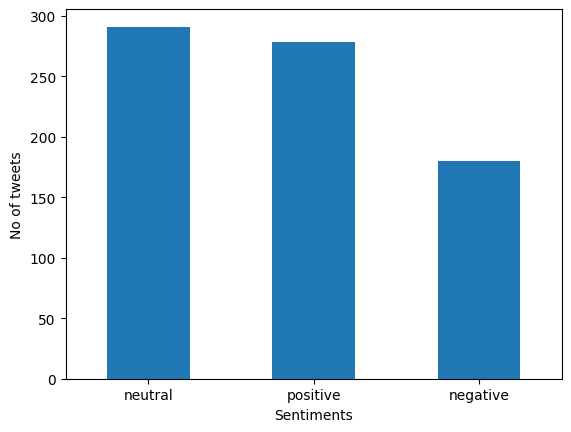

In [ ]:
df['sentiment'].value_counts().plot(kind='bar')
plt.xlabel('Sentiments')
plt.ylabel('No of tweets')
plt.xticks(rotation='horizontal')
plt.show()

*We get the preprocessed dataframe above. Now we are going to pass the processed texts to various NLP models for extracting the sentimental scores.*

*We are mainly using the following models for extrating the sentiment scores:*

*   *VADER*
*   *RoBERTa*
*   * *






# VADER Sentiment Analyzing

*First we are using VADER which is a lexicon based NLP tool,splitting each sentences into words and extract the polarity score associated with each word, and calculating a sentiment score based on the individual scores using some mathematical formula.*

In [ ]:
# necessary libray associated with vader
from nltk.sentiment import SentimentIntensityAnalyzer
nltk.download('vader_lexicon')

# For tracking
from tqdm.notebook import tqdm

# creating a object
sia = SentimentIntensityAnalyzer()

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


In [ ]:
# test case 1 - before injecting crypto related sentiment terms
sia.polarity_scores('BTC is bullish and heading to ATH, HODL!')

{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}

In [ ]:
# Crypto-specific sentiment terms
CRYPTO_LEXICON = {
    "bullish": 3.2,
    "bearish": -3.1,
    "hodl": 2.4,
    "fomo": -1.9,
    "ath": 3.4,
    "moon": 3.5,
    "pump": 2.8,
    "dump": -2.9,
    "rekt": -3.6,
    "rugpull": -3.9,
    "scam": -4.0,
    "crash": -3.5,
    "breakout": 3.0,
    "accumulate": 2.1,
    "selloff": -2.6,
}

# Loughran–McDonald inspired financial terms
FINANCIAL_LEXICON = {
    "profit": 2.7,
    "profits": 2.8,
    "growth": 2.4,
    "loss": -2.7,
    "losses": -2.9,
    "decline": -2.4,
    "risk": -1.8,
    "uncertainty": -1.7,
    "bankruptcy": -3.5,
    "fraud": -4.0,
    "regulation": -1.6,
    "ban": -3.0,
    "lawsuit": -3.1,
}

In [ ]:
# Merge custom lexicons
CUSTOM_LEXICON = {}
CUSTOM_LEXICON.update(CRYPTO_LEXICON)
CUSTOM_LEXICON.update(FINANCIAL_LEXICON)

# Inject into VADER
sia.lexicon.update(CUSTOM_LEXICON)


In [ ]:
# test case 1 - after injecting crypto related sentiment terms
sia.polarity_scores('BTC is bullish and heading to ATH, HODL!')

{'neg': 0.0, 'neu': 0.267, 'pos': 0.733, 'compound': 0.9409}

*it has the following output of scores (negative, neutral, positive and compound). Compound is the aggregation of negative, neutral and positive scores.*
*{'neg': 0.0, 'neu': 0.397, 'pos': 0.603, 'compound': 0.6771}*

In [ ]:
# test case 2
print(df.processed_text[71])
sia.polarity_scores(df.processed_text[71])

stacking sats every week way build wealth bitcoin


{'neg': 0.0, 'neu': 0.686, 'pos': 0.314, 'compound': 0.4939}

In [ ]:
# run the polarity_score on the entire dataset
result = {}
for idx, row in tqdm(df.iterrows(), total=len(df)):
  text = row['processed_text']
  result[idx] = sia.polarity_scores(text)

  0%|          | 0/749 [00:00<?, ?it/s]

In [ ]:
# so all the rows are having now vader values
len(result)

749

In [ ]:
# here we storing vader_sentiment_scores into a dataframe and merging it with the original df on the basis of 'id'
vader = pd.DataFrame(result).T
vader = vader.reset_index().rename(columns={'index': 'id'})
vader = df.merge(vader, how='left')
vader.head()

,id,timestamp,tweet,sentiment,processed_text,neg,neu,pos,compound
0,0,2024-01-07 02:00:00,Sold all my BTC. Too risky and unpredictable for me. #Bitcoin,negative,sold btc risky unpredictable bitcoin,0.31,0.690,0.000,-0.2023
1,1,2024-01-30 11:00:00,比特币是庞氏骗局 #比特币 #骗局,negative,比特币是庞氏骗局 #比特币 #骗局,0.00,1.000,0.000,0.0000
2,2,2024-01-02 12:00:00,Sovereign individual through Bitcoin! #BTC #Freedom,positive,sovereign individual bitcoin btc freedom,0.00,0.488,0.512,0.6369
3,3,2024-01-13 22:00:00,Institutional adoption of BTC continues to grow. This is just the beginning. #Bitcoin,positive,institutional adoption btc continues grow beginning bitcoin,0.00,1.000,0.000,0.0000
4,4,2024-01-03 10:00:00,Bitcoin reaching new highs in my country! 🇮🇳 #Bitcoin,positive,bitcoin reaching new highs country 🇮🇳 bitcoin,0.00,0.769,0.231,0.2023


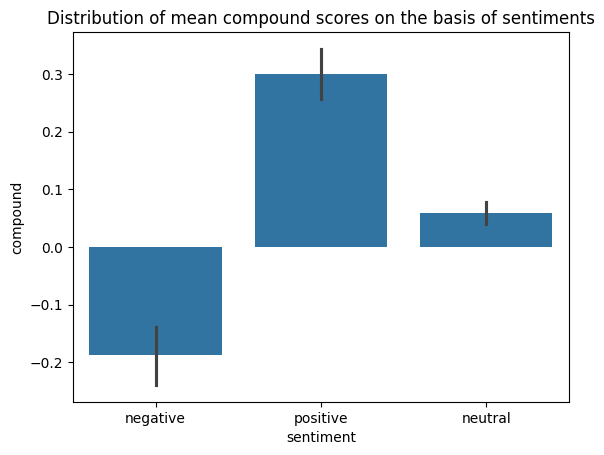

In [ ]:
sns.barplot(data=vader, x='sentiment', y='compound')
plt.title('Distribution of mean compound scores on the basis of sentiments')
plt.show()

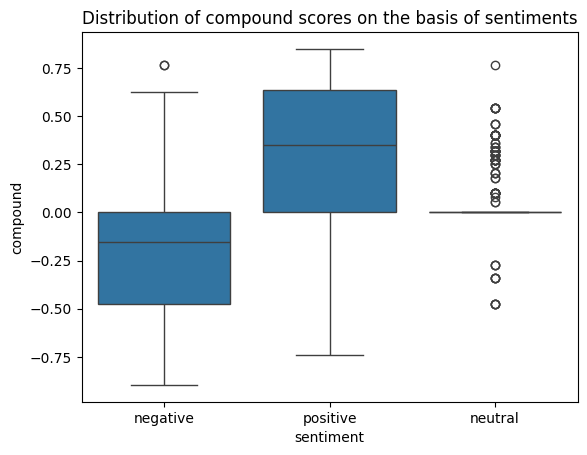

In [ ]:
sns.boxplot(data=vader, x='sentiment', y='compound')
plt.title('Distribution of compound scores on the basis of sentiments')
plt.show()

*From the above plots we can understand that the compound score:*


*   *below -0.05 gives negative sentiment*
*   *betweeen -0.05 and +0.05 gives neutral sentiment*
*   *Greater than +0.05 gives positive sentiment*



In [ ]:
# converting the vader compound scores to labels
def sentiment_converter_vader(score):
  if score < -0.05:
    return 'negative'
  elif score > 0.05:
    return 'positive'
  else:
    return 'neutral'

In [ ]:
vader['vader_sentiment'] = vader['compound'].apply(sentiment_converter_vader)

In [ ]:
vader.sample(5)

,id,timestamp,tweet,sentiment,processed_text,neg,neu,pos,compound,vader_sentiment
538,538,2024-01-29 22:00:00,BTC holding strong above $40k. Next stop: all-time highs! 🚀 #BitcoinNews,positive,btc holding strong next stop time highs 🚀,0.21,0.476,0.314,0.2732,positive
725,725,2024-01-10 22:00:00,Bitcoin crashed again. I'm done with crypto. #BTC #CryptoWinter,negative,bitcoin crashed done crypto btc,0.00,1.000,0.000,0.0000,neutral
192,192,2024-01-21 20:00:00,学习比特币改变了我的生活 🚀 #比特币 #BTC,positive,学习比特币改变了我的生活 🚀 #比特币 #BTC,0.00,1.000,0.000,0.0000,neutral
485,485,2024-01-16 19:00:00,Bitcoin fixes this. Period. #Bitcoin #BTC,positive,bitcoin fixes period bitcoin btc,0.00,1.000,0.000,0.0000,neutral
508,508,2024-01-26 10:00:00,My Bitcoin stack keeps growing! 📈 #HODL #BTC,positive,bitcoin stack keeps growing 📈 hold btc,0.00,0.746,0.254,0.1779,positive


In [ ]:
# now we takking some essential rows from it
vader_final = vader[['id', 'tweet', 'sentiment', 'compound', 'vader_sentiment']]
vader_final.head()

,id,tweet,sentiment,compound,vader_sentiment
0,0,Sold all my BTC. Too risky and unpredictable for me. #Bitcoin,negative,-0.2023,negative
1,1,比特币是庞氏骗局 #比特币 #骗局,negative,0.0000,neutral
2,2,Sovereign individual through Bitcoin! #BTC #Freedom,positive,0.6369,positive
3,3,Institutional adoption of BTC continues to grow. This is just the beginning. #Bitcoin,positive,0.0000,neutral
4,4,Bitcoin reaching new highs in my country! 🇮🇳 #Bitcoin,positive,0.2023,positive


In [ ]:
# accuracy
accuracy = accuracy_score(vader_final['sentiment'], vader_final['vader_sentiment'])
print('Vader model accuracy: ', accuracy)

Vader model accuracy:  0.6608811748998665


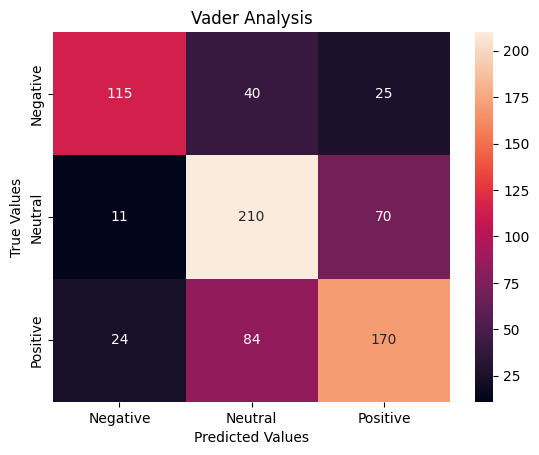

In [ ]:
# The corner values gives the correct predictions
labels = ['Negative', 'Neutral', 'Positive']
cm = confusion_matrix(vader_final['sentiment'], vader['vader_sentiment'])
sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels)
plt.title('Vader Analysis')
plt.ylabel('True Values')
plt.xlabel('Predicted Values')
plt.show()

In [ ]:
# classification report
cr = classification_report(vader_final['sentiment'], vader_final['vader_sentiment'])
print(cr)

              precision    recall  f1-score   support

    negative       0.77      0.64      0.70       180
     neutral       0.63      0.72      0.67       291
    positive       0.64      0.61      0.63       278

    accuracy                           0.66       749
   macro avg       0.68      0.66      0.67       749
weighted avg       0.67      0.66      0.66       749



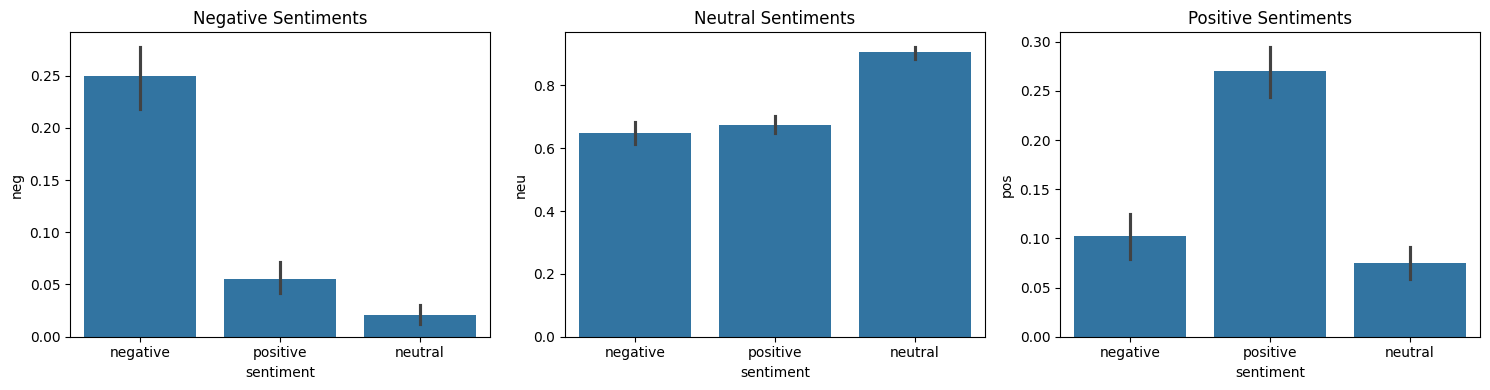

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
sns.barplot(data=vader, x='sentiment', y='neg', ax=ax[0])
sns.barplot(data=vader, x='sentiment', y='neu', ax=ax[1])
sns.barplot(data=vader, x='sentiment', y='pos', ax=ax[2])
ax[0].set_title('Negative Sentiments')
ax[1].set_title('Neutral Sentiments')
ax[2].set_title('Positive Sentiments')
plt.tight_layout()
plt.show()

*Fram the above plot the negativity of negative sentiments are greater. Similarly for both neutral and postive sentiment tweets. But a lot of sentiments are missclassified. A lot of neutrals are missclassified as positives and negatives.*

*VADER produces above avg scores and gives approximately 66% accuracy and missing a lot of values as per the above confusion matrix representation.*

# RoBERTa Sebtiment Analysis

*Roberta is a tranformer based model trained of a large corpus of data, it accounts for the words but also the context releted to other words.*

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from scipy.special import softmax

In [ ]:
MODEL = 'cardiffnlp/twitter-xlm-roberta-base-sentiment'
tokenizer = AutoTokenizer.from_pretrained(MODEL)
model = AutoModelForSequenceClassification.from_pretrained(MODEL)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/841 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

In [ ]:
# Testcase rub in VADER
example = "paul krugman, nobel luddite. tweak nose bitcoin enemy. says foolish things. link: htt…"
sia.polarity_scores(example)

{'neg': 0.337, 'neu': 0.663, 'pos': 0.0, 'compound': -0.6808}

In [ ]:
# The above same testcase run on RoBERTa
encoded_text = tokenizer(example, return_tensors='pt')
output = model(**encoded_text)
scores = output[0][0].detach().numpy()
scores = softmax(scores)
scores

# output: in the form of probabilities -> [negative, neutral, positive]

array([0.8179486 , 0.14857543, 0.03347607], dtype=float32)

In [ ]:
def roberta_predictions(text):
  encoded_text = tokenizer(text, return_tensors='pt')
  output = model(**encoded_text)
  scores = output[0][0].detach().numpy()
  scores = softmax(scores)
  scores_dict = {
      'roberta_neg': scores[0],
      'roberta_neu': scores[1],
      'roberta_pos': scores[2]
  }
  return scores_dict

In [ ]:
df.head()

,id,timestamp,tweet,sentiment,processed_text
0,0,2024-01-07 02:00:00,Sold all my BTC. Too risky and unpredictable for me. #Bitcoin,negative,sold btc risky unpredictable bitcoin
1,1,2024-01-30 11:00:00,比特币是庞氏骗局 #比特币 #骗局,negative,比特币是庞氏骗局 #比特币 #骗局
2,2,2024-01-02 12:00:00,Sovereign individual through Bitcoin! #BTC #Freedom,positive,sovereign individual bitcoin btc freedom
3,3,2024-01-13 22:00:00,Institutional adoption of BTC continues to grow. This is just the beginning. #Bitcoin,positive,institutional adoption btc continues grow beginning bitcoin
4,4,2024-01-03 10:00:00,Bitcoin reaching new highs in my country! 🇮🇳 #Bitcoin,positive,bitcoin reaching new highs country 🇮🇳 bitcoin


In [ ]:
result = {}
for idx, row in tqdm(df.iterrows(), total = len(df)):
  text = row['processed_text']
  result[idx] = roberta_predictions(text)

  0%|          | 0/749 [00:00<?, ?it/s]

*From the above steps we can understand that the roberta model taking a lot of time for predicting sentimentals in the tweets, ie*

In [ ]:
len(result)

749

In [ ]:
roberta = pd.DataFrame(result).T
roberta = roberta.reset_index().rename(columns={'index':'id'})
roberta = df.merge(roberta, how='left')
roberta.head()

,id,timestamp,tweet,sentiment,processed_text,roberta_neg,roberta_neu,roberta_pos
0,0,2024-01-07 02:00:00,Sold all my BTC. Too risky and unpredictable for me. #Bitcoin,negative,sold btc risky unpredictable bitcoin,0.541334,0.413180,0.045486
1,1,2024-01-30 11:00:00,比特币是庞氏骗局 #比特币 #骗局,negative,比特币是庞氏骗局 #比特币 #骗局,0.712300,0.260585,0.027115
2,2,2024-01-02 12:00:00,Sovereign individual through Bitcoin! #BTC #Freedom,positive,sovereign individual bitcoin btc freedom,0.173628,0.628699,0.197673
3,3,2024-01-13 22:00:00,Institutional adoption of BTC continues to grow. This is just the beginning. #Bitcoin,positive,institutional adoption btc continues grow beginning bitcoin,0.069063,0.609007,0.321930
4,4,2024-01-03 10:00:00,Bitcoin reaching new highs in my country! 🇮🇳 #Bitcoin,positive,bitcoin reaching new highs country 🇮🇳 bitcoin,0.090836,0.401397,0.507767


In [ ]:
roberta.isna().sum()

,0
id,0
timestamp,0
tweet,0
sentiment,0
processed_text,0
roberta_neg,0
roberta_neu,0
roberta_pos,0


In [ ]:
def roberta_sentiments(row):
  scores = {
      'negative': row['roberta_neg'],
      'neutral': row['roberta_neu'],
      'positive': row['roberta_pos']
  }
  return max(scores, key=scores.get)

roberta['predictions'] = roberta.apply(roberta_sentiments, axis=1)

In [ ]:
roberta.head()

,id,timestamp,tweet,sentiment,processed_text,roberta_neg,roberta_neu,roberta_pos,predictions
0,0,2024-01-07 02:00:00,Sold all my BTC. Too risky and unpredictable for me. #Bitcoin,negative,sold btc risky unpredictable bitcoin,0.541334,0.413180,0.045486,negative
1,1,2024-01-30 11:00:00,比特币是庞氏骗局 #比特币 #骗局,negative,比特币是庞氏骗局 #比特币 #骗局,0.712300,0.260585,0.027115,negative
2,2,2024-01-02 12:00:00,Sovereign individual through Bitcoin! #BTC #Freedom,positive,sovereign individual bitcoin btc freedom,0.173628,0.628699,0.197673,neutral
3,3,2024-01-13 22:00:00,Institutional adoption of BTC continues to grow. This is just the beginning. #Bitcoin,positive,institutional adoption btc continues grow beginning bitcoin,0.069063,0.609007,0.321930,neutral
4,4,2024-01-03 10:00:00,Bitcoin reaching new highs in my country! 🇮🇳 #Bitcoin,positive,bitcoin reaching new highs country 🇮🇳 bitcoin,0.090836,0.401397,0.507767,positive


In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(roberta['sentiment'], roberta['predictions'])
print('Roberta model accuracy: ', accuracy)

Roberta model accuracy:  0.6835781041388518


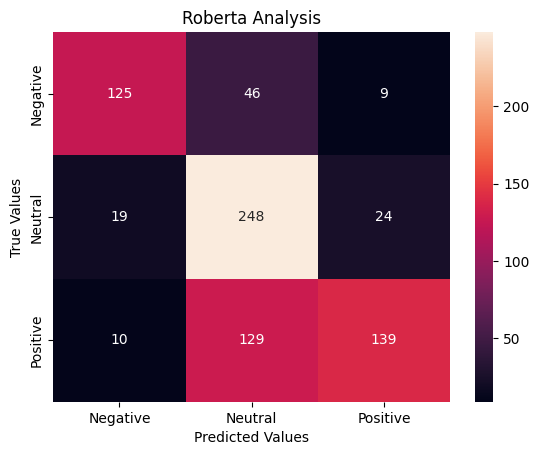

In [ ]:
# The corner values gives the correct predictions
labels = ['Negative', 'Neutral', 'Positive']
cm = confusion_matrix(roberta['sentiment'], roberta['predictions'])
sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels)
plt.title('Roberta Analysis')
plt.ylabel('True Values')
plt.xlabel('Predicted Values')
plt.show()

In [ ]:
# classification report
cr = classification_report(roberta['sentiment'], roberta['predictions'])
print(cr)

              precision    recall  f1-score   support

    negative       0.81      0.69      0.75       180
     neutral       0.59      0.85      0.69       291
    positive       0.81      0.50      0.62       278

    accuracy                           0.68       749
   macro avg       0.74      0.68      0.69       749
weighted avg       0.72      0.68      0.68       749



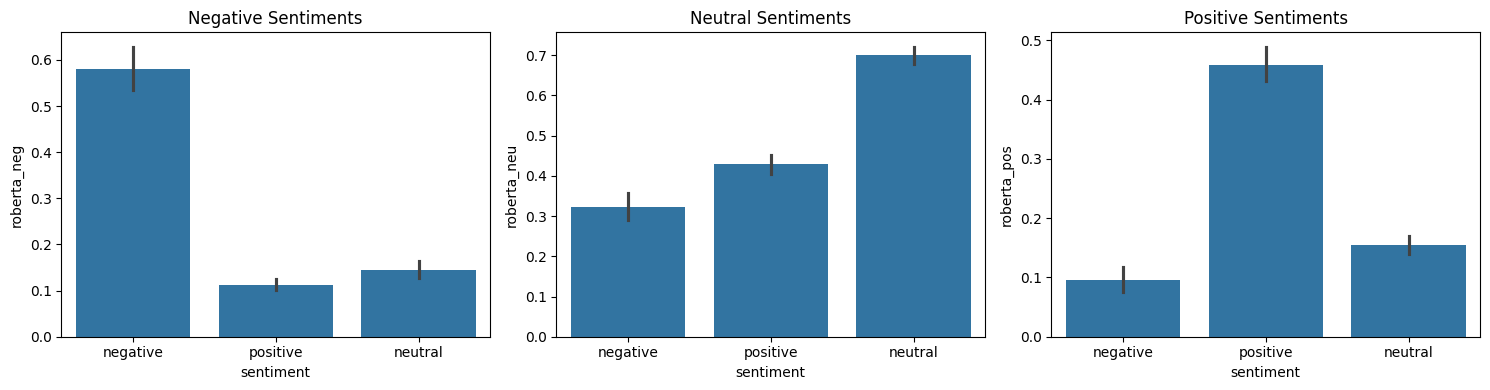

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
sns.barplot(data=roberta, x='sentiment', y='roberta_neg', ax=ax[0])
sns.barplot(data=roberta, x='sentiment', y='roberta_neu', ax=ax[1])
sns.barplot(data=roberta, x='sentiment', y='roberta_pos', ax=ax[2])
ax[0].set_title('Negative Sentiments')
ax[1].set_title('Neutral Sentiments')
ax[2].set_title('Positive Sentiments')
plt.tight_layout()
plt.show()

*The tweets used for model evaluation is bot generated, not accurate scoring. But the predictions using both vader and roberta is really good.*


*   *VADER scores 66% accurcy and good other classifcation metrics*
*   *RoBERTa also impressive and scores 68% accurcy and good other classifcation metrics*

*Now we are compining these models and evaluating it with the dataset*



# Combining model (VADER + RoBERTa) as feature engineering vectors

*What we are doing in here that, VADER and RoBERTa are used as independent sentiment feature generators; their aggregated outputs over fixed time intervals are concatenated with market indicators (OHLCV + technical indicators) to form composite input vectors for a crypto market prediction model.*

*For each time interval t (e.g., 1 hour or 1 day):*

*   *VADER → produces a continuous sentiment signal*
*   *RoBERTa → produces a probability-based sentiment signal*


*These become numerical input features to a separate crypto market trend prediction model.*

In [ ]:
vader.head(2)

,id,timestamp,tweet,sentiment,processed_text,neg,neu,pos,compound,vader_sentiment
0,0,2024-01-07 02:00:00,Sold all my BTC. Too risky and unpredictable for me. #Bitcoin,negative,sold btc risky unpredictable bitcoin,0.31,0.69,0.0,-0.2023,negative
1,1,2024-01-30 11:00:00,比特币是庞氏骗局 #比特币 #骗局,negative,比特币是庞氏骗局 #比特币 #骗局,0.00,1.00,0.0,0.0000,neutral


*VADER produces a four-dimensional sentiment output:*

**`s(VADER) = [s(pos), s(neu), s(neg), s(compound)]`**

*where s(pos), s(neu), and s(neg) correspond to the positive,
neutral, and negative sentiment proportions, and s(compound) is a normalized aggregation of the valence scores ranging from
−1 (most negative) to +1 (most positive). We use s(compound)
as a single quantitative measure of overall tweet sentiment.*

In [ ]:
vader_df = vader[['timestamp', 'compound']]
vader_df = vader_df.sort_values(by='timestamp')
vader_df = vader_df.reset_index(drop=True)
vader_df = vader_df.reset_index().rename(columns={'index': 'id'})
display(vader_df.head()), vader_df.shape

,id,timestamp,compound
0,0,2024-01-01 00:00:00,0.4404
1,1,2024-01-01 01:00:00,0.0000
2,2,2024-01-01 04:00:00,0.0000
3,3,2024-01-01 05:00:00,0.0000
4,4,2024-01-01 07:00:00,0.6369


(None, (749, 3))

In [ ]:
roberta.head(2)

,id,timestamp,tweet,sentiment,processed_text,roberta_neg,roberta_neu,roberta_pos,predictions
0,0,2024-01-07 02:00:00,Sold all my BTC. Too risky and unpredictable for me. #Bitcoin,negative,sold btc risky unpredictable bitcoin,0.541334,0.413180,0.045486,negative
1,1,2024-01-30 11:00:00,比特币是庞氏骗局 #比特币 #骗局,negative,比特币是庞氏骗局 #比特币 #骗局,0.712300,0.260585,0.027115,negative


*RoBERTa model assigns softmax probabilities to three sentiment classes: positive, neutral, and negative:*

**`s(RoBERTa) = [P(pos), P(neu), P(neg)]`**

*where P(pos), P(neu), and P(neg)
represent the softmax normalized probabilities of a tweet belonging to each sentiment class. These probabilities are computed as:*

*`P(c) =​ exp(zc) ​/ ∑ exp(zj)`*

*where zc is the logit output for class c (positive, neutral, or
negative), and the softmax function ensures the sum of all
class probabilities equals 1.*

*We define the sentiment composite score based on the highest-probability predicted sentiment:*

*`s(RoBERTa) = arg max P(c)`*

*where the probability of the selected sentiment class is
used as the sentiment intensity score.*

In [ ]:
roberta_df = roberta[['timestamp', 'predictions']]
roberta_df = roberta_df.sort_values(by='timestamp')
roberta_df = roberta_df.reset_index(drop=True)
roberta_df = roberta_df.reset_index().rename(columns={'index': 'id'})
display(roberta_df.head()), roberta_df.shape

,id,timestamp,predictions
0,0,2024-01-01 00:00:00,negative
1,1,2024-01-01 01:00:00,positive
2,2,2024-01-01 04:00:00,neutral
3,3,2024-01-01 05:00:00,neutral
4,4,2024-01-01 07:00:00,positive


(None, (749, 3))

*In roberta, a sentiment label is asssigned based on the predicted class as:*

*   *label = 2, if arg max(P(pos), P(neu), P(neg)) = P(pos)*
*   *label = 1, if arg max(P(pos), P(neu), P(neg)) = P(neu)*
*   *label = -1, if arg max(P(pos), P(neu), P(neg)) = P(neg)*



In [ ]:
def assigning_sentiment_label(pred_class):
  if pred_class == 'negative':
    label = -1
  elif pred_class == 'neutral':
    label = 1
  elif pred_class == 'positive':
    label = 2
  return label

In [ ]:
roberta_df['label'] = roberta_df['predictions'].apply(assigning_sentiment_label)
roberta_df = roberta_df.drop('predictions', axis=1)
roberta_df.head()

,id,timestamp,label
0,0,2024-01-01 00:00:00,-1
1,1,2024-01-01 01:00:00,2
2,2,2024-01-01 04:00:00,1
3,3,2024-01-01 05:00:00,1
4,4,2024-01-01 07:00:00,2


*For each time interval t (e.g., a day), we aggregate sentiment
scores:*


*   *For vader, Vt​ = 1/Nt ∑ Si(VADER)​*
*   *For roberta, Rt​ = 1/Nt ∑ Si(RoBERTa)*

*where, t = time window (e.g., day)*

*Nt = number of tweets in that window*



In [ ]:
# combining both the dataset using timrstamp annd id
combined_df = pd.merge(vader_df, roberta_df, on=('id', 'timestamp'), how='inner')
combined_df = combined_df.rename(columns={'compound': 'vader_score', 'label': 'roberta_score'})
combined_df

,id,timestamp,vader_score,roberta_score
0,0,2024-01-01 00:00:00,0.4404,-1
1,1,2024-01-01 01:00:00,0.0000,2
2,2,2024-01-01 04:00:00,0.0000,1
3,3,2024-01-01 05:00:00,0.0000,1
4,4,2024-01-01 07:00:00,0.6369,2
...,...,...,...,...
744,744,2024-01-30 21:00:00,0.7717,2
745,745,2024-01-30 22:00:00,0.0000,1
746,746,2024-01-30 23:00:00,-0.7906,-1
747,747,2024-01-30 23:00:00,0.0000,1


In [ ]:
combined_df = combined_df.drop('id', axis=1)
combined_df = combined_df.set_index('timestamp')

In [ ]:
# aggregate scores based on day
aggregated_df = combined_df.resample('D').mean()
aggregated_df.shape

(31, 2)

In [ ]:
aggregated_df

,vader_score,roberta_score
timestamp,,
2024-01-01,0.144896,0.851852
2024-01-02,0.182936,0.928571
2024-01-03,0.044325,1.000000
2024-01-04,0.068221,0.625000
2024-01-05,0.159544,0.925926
2024-01-06,0.153137,0.947368
2024-01-07,-0.006832,0.954545
2024-01-08,0.082186,0.931034
2024-01-09,0.165535,0.846154


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

aggregated_df[['vader_norm', 'roberta_norm']] = scaler.fit_transform(
    aggregated_df[['vader_score', 'roberta_score']]
)


In [ ]:
aggregated_df

,vader_score,roberta_score,vader_norm,roberta_norm
timestamp,,,,
2024-01-01,0.144896,0.851852,0.785825,0.785185
2024-01-02,0.182936,0.928571,0.929326,0.896429
2024-01-03,0.044325,1.000000,0.406425,1.000000
2024-01-04,0.068221,0.625000,0.496571,0.456250
2024-01-05,0.159544,0.925926,0.841084,0.892593
2024-01-06,0.153137,0.947368,0.816912,0.923684
2024-01-07,-0.006832,0.954545,0.213439,0.934091
2024-01-08,0.082186,0.931034,0.549254,0.900000
2024-01-09,0.165535,0.846154,0.863681,0.776923
